1. Criticality Analysis
2. Failure Simulation
3. Route Recommendation
4. Resilience Dashboard Metrics

In [2]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

import segmentation_models_pytorch as smp

from skimage.morphology import skeletonize
import networkx as nx

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

model.load_state_dict(
    torch.load(
        "deeplabv3plus_road.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [4]:
test_id = "227114"

img = cv2.imread(f"train/{test_id}_sat.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(
    img_rgb,
    (512,512)
)

x = img_resized.astype(np.float32) / 255.0

x = torch.tensor(
    x.transpose(2,0,1)
).unsqueeze(0)

x = x.to(device)

with torch.no_grad():
    pred = model(x)

pred = torch.sigmoid(pred)
pred = pred.squeeze().cpu().numpy()

pred_binary = (
    pred > 0.5
).astype(np.uint8)

print("Road %:",
      100*np.sum(pred_binary)/pred_binary.size)

print(pred_binary.shape)

Road %: 12.35809326171875
(512, 512)


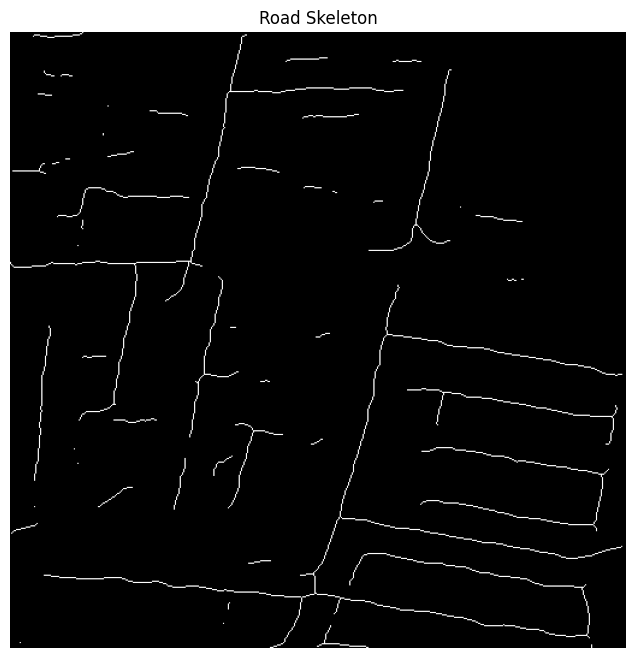

Skeleton Pixels: 4153


In [5]:
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt

road_mask = pred_binary.astype(bool)

skeleton = skeletonize(road_mask)

plt.figure(figsize=(8,8))
plt.imshow(skeleton, cmap="gray")
plt.title("Road Skeleton")
plt.axis("off")
plt.show()

print("Skeleton Pixels:", skeleton.sum())

In [6]:
import networkx as nx
import numpy as np

G = nx.Graph()

coords = np.argwhere(skeleton)

for y, x in coords:
    G.add_node((y, x))

coord_set = set(map(tuple, coords))

for y, x in coords:

    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:

            if dy == 0 and dx == 0:
                continue

            ny = y + dy
            nx_ = x + dx

            if (ny, nx_) in coord_set:
                G.add_edge((y, x), (ny, nx_))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Components:", nx.number_connected_components(G))


largest_component = max(
    nx.connected_components(G),
    key=len
)

G_main = G.subgraph(
    largest_component
).copy()

junction_nodes = [
    n
    for n in G_main.nodes()
    if G_main.degree(n) >= 3
]

print("Junctions:", len(junction_nodes))

print(
    "Main Nodes:",
    G_main.number_of_nodes()
)

print(
    "Main Edges:",
    G_main.number_of_edges()
)

print(type(G_main))

Nodes: 4153
Edges: 4133
Components: 52
Junctions: 22
Main Nodes: 1460
Main Edges: 1467
<class 'networkx.classes.graph.Graph'>


In [ ]:
bet = nx.betweenness_centrality(
    G_main,
    normalized=True
)

junction_nodes = [
    n
    for n in G_main.nodes()
    if G_main.degree(n) >= 3
]

critical_junctions = sorted(
    [
        (n, bet[n])
        for n in junction_nodes
    ],
    key=lambda x: x[1],
    reverse=True
)

print(
    critical_junctions[:10]
)


[((402, 274), 0.5744167745538548), ((465, 253), 0.49922387038118254), ((451, 252), 0.49813136569666916), ((449, 252), 0.4967868891916311), ((466, 254), 0.4459619165277531), ((470, 274), 0.43654117905888523), ((470, 275), 0.4294991307912385), ((470, 242), 0.3045154666508714), ((466, 253), 0.30441392576797344), ((501, 478), 0.28597297320166865)]
Graph Saved


In [23]:
critical_node = critical_junctions[9][0]

G_fail = G_main.copy()

before = nx.number_connected_components(
    G_fail
)

G_fail.remove_node(
    critical_node
)

after = nx.number_connected_components(
    G_fail
)

print("Before:", before)
print("After :", after)

resilience_score = before / after

print(
    "Resilience Score:",
    resilience_score
)

Before: 1
After : 2
Resilience Score: 0.5


In [24]:
nodes = list(G_main.nodes())

source = nodes[100]
target = nodes[1000]

print("Source:", source)
print("Target:", target)

Source: (460, 467)
Target: (427, 414)


In [25]:
path_before = nx.shortest_path(
    G_main,
    source,
    target
)

print(
    "Original Route Length:",
    len(path_before)
)

Original Route Length: 476


In [27]:
try:

    path_after = nx.shortest_path(
        G_fail,
        source,
        target
    )

    print(
        "Alternate Route Length:",
        len(path_after)
    )

    print(
        "Extra Distance:",
        len(path_after)
        -
        len(path_before)
    )

except:

    print(
        "Route Not Available"
    )

Route Not Available


In [31]:
critical_node = (450, 252)

G_fail = G_main.copy()

G_fail.remove_node(
    critical_node
)

print(
    nx.number_connected_components(G_fail)
)

1


In [32]:
print(
    nx.has_path(
        G_fail,
        source,
        target
    )
)

True


In [33]:
path_before = nx.shortest_path(
    G_main,
    source,
    target
)

path_after = nx.shortest_path(
    G_fail,
    source,
    target
)

print(
    "Original Length:",
    len(path_before)
)

print(
    "Alternate Length:",
    len(path_after)
)

print(
    "Extra Distance:",
    len(path_after)
    -
    len(path_before)
)

Original Length: 476
Alternate Length: 476
Extra Distance: 0


In [36]:
for node, score in critical_junctions[:10]:

    G_test = G_main.copy()
    G_test.remove_node(node)

    try:

        p1 = nx.shortest_path_length(
            G_main,
            source,
            target
        )

        p2 = nx.shortest_path_length(
            G_test,
            source,
            target
        )

        print(
            "Node:", node,
            "Original:", p1,
            "New:", p2,
            "Diff:", p2-p1
        )

    except:
        print(
            "Node:", node,
            "Disconnected"
        )

Node: (402, 274) Disconnected
Node: (465, 253) Disconnected
Node: (451, 252) Disconnected
Node: (449, 252) Disconnected
Node: (466, 254) Disconnected
Node: (470, 274) Disconnected
Node: (470, 275) Disconnected
Node: (470, 242) Original: 458 New: 458 Diff: 0
Node: (466, 253) Original: 458 New: 458 Diff: 0
Node: (501, 478) Disconnected
